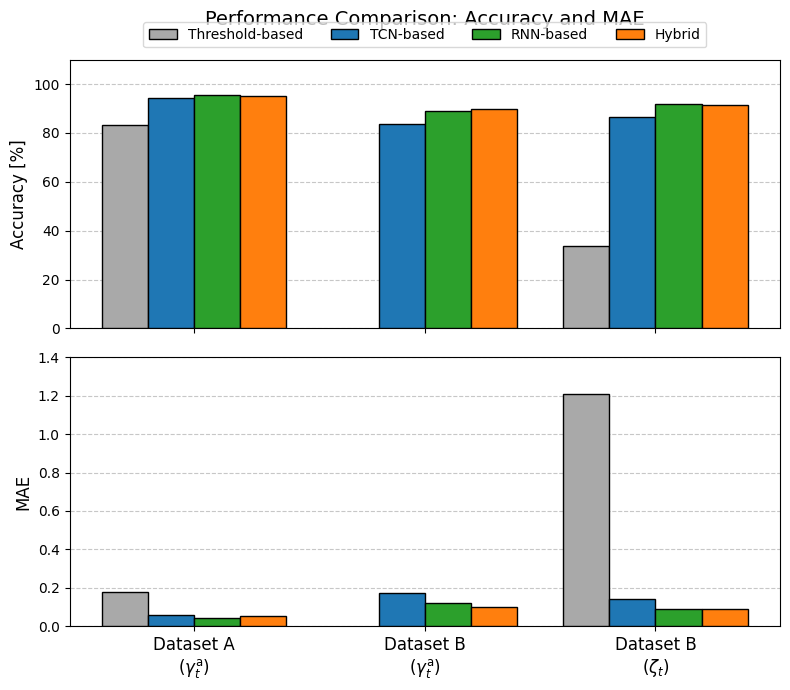

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# --- Formatting variables matching your style ---
title_fontsize = 14
label_fontsize = 12
tick_fontsize = 10
legend_fontsize = 10
fig_width = 8
fig_height = 7

# --- Table Data ---
# Scenarios: 
# 0 = Dataset A, Features: \gamma^a_t (Activations only)
# 1 = Dataset B, Features: \gamma^a_t (Activations & Deactivations)
# 2 = Dataset B, Features: \zeta_t    (Activations & Deactivations)
scenarios = [
    r"Dataset A" + "\n" + r"($\gamma^{\mathrm{a}}_t$)", 
    r"Dataset B" + "\n" + r"($\gamma^{\mathrm{a}}_t$)", 
    r"Dataset B" + "\n" + r"($\zeta_t$)"
]

# Detector Methods
methods = ['Threshold-based', 'TCN-based', 'RNN-based', 'Hybrid']

# Accuracy [%] (np.nan for missing entries to not plot a bar)
#            A(\gamma) | B(\gamma) | B(\zeta)
acc_data = {
    'Threshold-based': [83.1, np.nan, 33.6],
    'TCN-based':       [94.2, 83.8,  86.4],
    'RNN-based':       [95.6, 89.0,  91.9],
    'Hybrid':          [95.2, 90.0,  91.3]
}

# Mean Absolute Error (MAE)
mae_data = {
    'Threshold-based': [0.18, np.nan, 1.21],
    'TCN-based':       [0.06, 0.17, 0.14],
    'RNN-based':       [0.04, 0.12, 0.09],
    'Hybrid':          [0.05, 0.10, 0.09]
}

# --- Plotting ---
fig, axs = plt.subplots(2, 1, figsize=(fig_width, fig_height), sharex=True, gridspec_kw={'height_ratios': [1, 1]})

x = np.arange(len(scenarios))
width = 0.2
colors = ['#A9A9A9', '#1f77b4', '#2ca02c', '#ff7f0e'] # Gray, Blue, Green, Orange

# 1. Accuracy Plot (Top)
multiplier = 0
for i, (method, acc) in enumerate(acc_data.items()):
    offset = width * multiplier
    bars = axs[0].bar(x + offset, acc, width, label=method, color=colors[i], edgecolor='black', zorder=3)
    multiplier += 1

axs[0].set_title("Performance Comparison: Accuracy and MAE", fontsize=title_fontsize, pad=25)
axs[0].set_ylabel("Accuracy [%]", fontsize=label_fontsize)
axs[0].tick_params(axis='y', labelsize=tick_fontsize)
axs[0].set_ylim(0, 110)
axs[0].grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
axs[0].legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=4, framealpha=0.75, fontsize=legend_fontsize)

# 2. MAE Plot (Bottom)
multiplier = 0
for i, (method, mae) in enumerate(mae_data.items()):
    offset = width * multiplier
    bars = axs[1].bar(x + offset, mae, width, label=method, color=colors[i], edgecolor='black', zorder=3)
    multiplier += 1

axs[1].set_ylabel("MAE", fontsize=label_fontsize)
axs[1].tick_params(axis='y', labelsize=tick_fontsize)
axs[1].set_ylim(0, 1.4)
axs[1].grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

# Setting the ticks and labels for the shared x-axis
axs[1].set_xticks(x + width * 1.5)
axs[1].set_xticklabels(scenarios, fontsize=label_fontsize)

# --- Final Touches ---
plt.tight_layout()

# Save output
plt.savefig("table_results_visualization.pdf", bbox_inches='tight', dpi=600)
plt.show()

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# --- Formatting variables matching your style ---
title_fontsize = 14
label_fontsize = 14
tick_fontsize = 14
legend_fontsize = 14
fig_width = 5.
fig_height = 5.

mpl.use("pgf")
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'pgf.preamble': r'\usepackage{amsmath,graphicx,siunitx,bm}' # Added bm for \bm command
})

# --- Table Data ---
# Scenarios: 
# 0 = Dataset A, Features: \gamma^a_t (Activations only)
# 1 = Dataset B, Features: \zeta_t    (Activations & Deactivations)
scenarios = [
    r"Dataset A" + "\n" + r"$\bm{\gamma}^{\mathrm{a}}_t$", 
    r"Dataset B" + "\n" + r"$[\bm{\gamma}^{\mathrm{a}}_t, \bm{\gamma}^{\mathrm{d}}_t]$"
]

# Detector Methods
methods = ['Threshold', 'TCN', 'RNN']

# Accuracy [%] 
#            A(\gamma) | B(\zeta)
acc_data = {
    'Threshold': [83.1, 33.6],
    'TCN':       [94.2, 86.4],
    'RNN':       [95.6, 91.9]
}

# Mean Absolute Error (MAE)
mae_data = {
    'Threshold': [0.18, 1.21],
    'TCN':       [0.06, 0.14],
    'RNN':       [0.04, 0.09]
}

# --- Plotting ---
fig, axs = plt.subplots(2, 1, figsize=(fig_width, fig_height), sharex=True, gridspec_kw={'height_ratios': [1, 1]})

x = np.arange(len(scenarios))
width = 0.15
# use the first three colors of seaborn color palette colorblind-friendly
import seaborn as sns
palette = sns.color_palette("colorblind", n_colors=3)
colors = palette.as_hex()


# colors = ['#A9A9A9', '#1f77b4', '#2ca02c'] # Gray, Blue, Green

# 1. Accuracy Plot (Top)
multiplier = 0
for i, (method, acc) in enumerate(acc_data.items()):
    offset = width * multiplier
    bars = axs[0].bar(x + offset, acc, width, label=method, color=colors[i], edgecolor='black', zorder=3)
    multiplier += 1

# axs[0].set_title("Performance Comparison: Accuracy and MAE", fontsize=title_fontsize, pad=25)
axs[0].set_ylabel("Accuracy [%]", fontsize=label_fontsize)
axs[0].tick_params(axis='y', labelsize=tick_fontsize)
axs[0].set_ylim(30, 100)
axs[0].grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

# 2. MAE Plot (Bottom)
multiplier = 0
for i, (method, mae) in enumerate(mae_data.items()):
    offset = width * multiplier
    bars = axs[1].bar(x + offset, mae, width, label=method, color=colors[i], edgecolor='black', zorder=3)
    multiplier += 1

axs[1].set_ylabel("MAE", fontsize=label_fontsize)
axs[1].tick_params(axis='y', labelsize=tick_fontsize)
axs[1].set_ylim(0, 1.25)
axs[1].grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

# Setting the ticks and labels for the shared x-axis (center is at offset width * 1)
axs[1].set_xticks(x + width)
axs[1].set_xticklabels(scenarios, fontsize=label_fontsize)
axs[1].legend(loc='upper left', ncol=1, framealpha=0.75, fontsize=legend_fontsize)
# axs[1].legend(loc='upper left', bbox_to_anchor=(1.02, 0.5), ncol=1, framealpha=0.75, fontsize=legend_fontsize)

# --- Final Touches ---
plt.tight_layout()

# Save output
plt.savefig("table_results_visualization_filtered.pdf", bbox_inches='tight', dpi=600)
plt.savefig("/data4/Henri/j3/framewiseSpeakerCounting/documents/presentation/figures_new/table_results_visualization_filtered.pdf", bbox_inches='tight', dpi=600)
plt.show()